In [35]:
import os, sys
module_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
if module_path not in sys.path:
    sys.path.append(module_path)
from utilities import *
import matplotlib.colors as mcolors
import itertools
from utilities.stim_utils import *
sns.set_context("talk")

In [36]:
df = pd.read_hdf('Data/TemporalNoise1f_v2.h5', key='data')
frame_rate = 60
window_size = 600/1000
bin_size = 1/frame_rate
nsims = 20
print(df['cell_type'].unique())
cell_type ='OFF transient alpha'
# cell_type = 'OFF sustained alpha'
# cell_type = 'ON alpha'
ctype_df = df[df['cell_type'] == cell_type]
cell_text = True
save = False
print('#'*60)
print('Processing cell type:', cell_type)

['OFF transient alpha' 'ON alpha' 'ON delayed' 'OFF sustained alpha']
############################################################
Processing cell type: OFF transient alpha


In [37]:
# fraction of variance retained (usually quite high)
# EPS_GRID     = np.linspace(	0.911, 1.00, 10)
EPS_GRID     = [1.00]
# number of bins for empirical NL (depends on spike counts, keep modest)
NBINS_GRID   = [20, 25, 30, 35, 40]
# ridge regularization strength (log-spaced)
ALPHA_GRID   = np.logspace(-5, 0, 5)          
LAMBDA_GRID  = np.logspace(-1, 3, 10)    

In [38]:
def poisson_ll(y_counts, rate_hz, bin_size, eps=1e-12):
    """Return Poisson log-likelihood (nats) ignoring log(y!) constant."""
    mu = np.clip(rate_hz * bin_size, eps, np.inf)
    y  = y_counts.astype(float)
    return float(np.sum(y * np.log(mu) - mu))

# --------------------------------------------------
# 0)  grids, bookkeeping, CV settings
# ddddfdf   
K_FOLDS      = 3                       # ← CV folds
rng_global   = np.random.default_rng(0)

best_models  = {}                      # key → dict
# --------------------------------------------------
# 1) iterate over cells
# --------------------------------------------------
for cell_name in ctype_df['cell_name'].unique():
    cell_df   = ctype_df.query(f"cell_name == '{cell_name}'").reset_index(drop=True)
    
    for beta in cell_df['beta'].unique():

        data       = cell_df.query(f"beta == {beta}").reset_index(drop=True)
        stim_nr    = np.stack(data.loc[data.noise_seed != 1, 'stimulus'])
        stim_rs    = np.stack(data.loc[data.noise_seed == 1, 'stimulus'])
        spk_nr     = np.stack(data.loc[data.noise_seed != 1, 'spike_train'])
        spk_rs     = np.stack(data.loc[data.noise_seed == 1, 'spike_train'])
        test_psth  = spk_rs.mean(axis=0) / bin_size

        n_trials, n_frames = stim_nr.shape
        ntfilt     = int(window_size / bin_size)

        # pre-compute Hankelised stimulus for every trial once
        hankel_list = []
        for tr in range(n_trials):
            pad        = np.hstack([np.zeros(ntfilt-1), stim_nr[tr].ravel()])
            design_tr  = hankel(pad[:-ntfilt+1], stim_nr[tr, -ntfilt:])
            hankel_list.append(design_tr)          # (frames, ntfilt)

        # lambda_grid = np.linspace(1e-2, 1e2, 40) if beta >= 1.5 else LAMBDA_GRID
        lambda_grid = LAMBDA_GRID
        # # --------------------------------------------------
        # 2)  GRID + K-fold CV
        # --------------------------------------------------
        idx = rng_global.permutation(n_trials)
        folds = np.array_split(idx, K_FOLDS)
        for eps, nbins, alpha, lam_s in itertools.product(
                EPS_GRID, NBINS_GRID, ALPHA_GRID, lambda_grid):

            cv_scores = []
            
            for k in range(K_FOLDS):
                # train / val indices
                val_idx = folds[k]
                trn_idx = np.hstack([folds[j] for j in range(K_FOLDS) if j != k])

                # ---- concatenate TRAIN trials ----
                design_trn = np.vstack([hankel_list[i] for i in trn_idx])
                spk_trn    = spk_nr[trn_idx].ravel()

                # ---- fit filter + NL on TRAIN ----
                rf_est, _, _, _ = whitened_reverse_correlation_smooth(
                    design_trn, spk_trn,
                    eps=eps, alpha=alpha, lambda_smooth=lam_s)

                # rf_est, _, _, _ = whitened_reverse_correlation_eps(
                #     design_trn, spk_trn,
                #     eps=eps, alpha=alpha)

                offset = spk_trn.mean() - (design_trn @ rf_est).mean()
                STA_norm = np.flip(rf_est / np.std(rf_est))

                L_train  = convolve_stimulus(stim_nr[trn_idx], STA_norm, mode='valid') + offset
                x_nl, eNL, f_NL = sNL(
                    L_train.ravel(), spk_nr[trn_idx][:, ntfilt-1:].ravel(),
                    nbins=nbins, plotflag=False)

                # ---- evaluate on VAL ----
                L_val   = convolve_stimulus(stim_nr[val_idx], STA_norm, 
                                               mode='valid') + offset
                Y_val = spk_nr[val_idx][:, ntfilt-1:] 
                rates = []
                for j in range(L_val.shape[0]):
                    _, rate_hz, _ = predict_FR(
                        Y_val[j]/bin_size, L_val[j], bin_size,
                        empirical_nl_f=f_NL, empirical_nl_d=eNL,
                        nonlinearity_type="empirical",
                        xinf=0, xsup=10, plotFlag=False)

                    # rate_hz = pred_fr * bin_size
                    rates.append(rate_hz)

                rate_cat = np.clip(np.concatenate(rates), 1e-12, None)
                Y_cat   = Y_val.ravel()
                
                # Null from TRAIN ONLY (Hz)
                train_counts = spk_nr[trn_idx][:, ntfilt-1:]
                train_mean_rate_hz = train_counts.sum() / (train_counts.size * bin_size)

                LL_model = poisson_ll(Y_cat, rate_cat, bin_size)
                LL_null  = poisson_ll(Y_cat, np.full_like(rate_cat, train_mean_rate_hz), bin_size)

                total_spikes = max(float(Y_cat.sum()), 1.0)
                bits_per_spike = (LL_model - LL_null) / (np.log(2) * total_spikes)
                cv_scores.append(bits_per_spike)
                
            mean_cv_bps = np.mean(cv_scores)

            # --------------------------------------------------
            # 3)  if best so far → refit on FULL training set
            # --------------------------------------------------
            key = (cell_name, beta)
            prev_best = best_models.get(key, {})        # empty dict if unseen
            prev_score = prev_best.get("bps_cv", -np.inf)

            if mean_cv_bps > prev_score:

                # ----- refit on *all* non-repeated trials -----
                design_full = np.vstack(hankel_list)
                spk_full    = spk_nr.ravel()

                rf_est, _, _, _ = whitened_reverse_correlation_smooth(
                    design_full, spk_full,
                    eps=eps, alpha=alpha, lambda_smooth=lam_s)
                # rf_est, _, _, _ = whitened_reverse_correlation_eps(
                #     design_full, spk_full,
                #     eps=eps, alpha=alpha)

                offset   = spk_full.mean() - (design_full @ rf_est).mean()
                STA_norm = np.flip(rf_est / np.std(rf_est))

                L_full   = convolve_stimulus(stim_nr, STA_norm, mode='valid') + offset
                x_nl, eNL, f_NL = sNL(
                    L_full.ravel(), spk_nr[:, ntfilt-1:].ravel(),
                    nbins=nbins, plotflag=False)

                # ----- predict repeated-stim TEST set -----
                test_stim, _ = signal_resample(stim_rs, frame_rate, 1/bin_size)
                test_L       = convolve_stimulus(test_stim, STA_norm) + offset
                test_L       = test_L.mean(axis=0)

                psth_cut = test_psth[ntfilt-1:]
                _, pred_fr, r2_test = predict_FR(
                    psth_cut, test_L, bin_size,
                    empirical_nl_f=f_NL, empirical_nl_d=eNL,
                    nonlinearity_type="empirical",
                    xinf=0, xsup=10, plotFlag=False)

                # ----- simulate Poisson repeats -----
                lam      = np.clip(pred_fr * bin_size, 0, None)
                rng_seed = hash((cell_name, beta, eps, nbins, alpha, lam_s)) 
                rng      = np.random.default_rng(np.abs(rng_seed))
                spk_sim  = rng.poisson(lam, size=(nsims, lam.size))
                psth_sim = spk_sim.mean(0) / bin_size

                best_models[key] = dict(
                    cell_type      = cell_type,
                    cell_name      = cell_name,
                    quadrant       = quadrant,
                    spot_size      = spot_size,
                    beta           = beta,
                    STA_norm       = STA_norm, #variance-normalized STA
                    rf_est         = rf_est,  #unnormalized STA
                    x_NL           = x_nl,
                    NL             = f_NL,
                    psth_real      = psth_cut,
                    psth_pred      = pred_fr,
                    spks_model     = spk_sim,
                    spks_data      = spk_nr,
                    psth_sim       = psth_sim,
                    stimulus       = stim_nr,
                    stim_rs        = stim_rs,
                    L_est_m        = L_full,
                    offset         = offset,
                    lambda_smooth  = lam_s,
                    eps            = eps,
                    nbins          = nbins,
                    alpha          = alpha,
                    bps_cv         = mean_cv_bps,
                    r2_test        = r2_test       #   plus test-set score
                )

Pearson R: 0.63
R^2: 0.40
Pearson R: 0.60
R^2: 0.35
Pearson R: 0.63
R^2: 0.39
Pearson R: 0.60
R^2: 0.34
Pearson R: 0.56
R^2: 0.29
Pearson R: 0.54
R^2: 0.14
Pearson R: 0.60
R^2: 0.23
Pearson R: 0.56
R^2: 0.13
Pearson R: 0.61
R^2: 0.37
Pearson R: 0.82
R^2: 0.29
Pearson R: 0.63
R^2: 0.40
Pearson R: 0.60
R^2: 0.35
Pearson R: 0.63
R^2: 0.39
Pearson R: 0.60
R^2: 0.34
Pearson R: 0.56
R^2: 0.29
Pearson R: 0.54
R^2: 0.14
Pearson R: 0.60
R^2: 0.23
Pearson R: 0.56
R^2: 0.13
Pearson R: 0.61
R^2: 0.37
Pearson R: 0.82
R^2: 0.29
Pearson R: 0.63
R^2: 0.40
Pearson R: 0.60
R^2: 0.35
Pearson R: 0.63
R^2: 0.39
Pearson R: 0.60
R^2: 0.34
Pearson R: 0.56
R^2: 0.29
Pearson R: 0.54
R^2: 0.14
Pearson R: 0.60
R^2: 0.23
Pearson R: 0.56
R^2: 0.13
Pearson R: 0.61
R^2: 0.38
Pearson R: 0.82
R^2: 0.29
Pearson R: 0.63
R^2: 0.40
Pearson R: 0.60
R^2: 0.36
Pearson R: 0.63
R^2: 0.39
Pearson R: 0.60
R^2: 0.33
Pearson R: 0.56
R^2: 0.29
Pearson R: 0.54
R^2: 0.14
Pearson R: 0.60
R^2: 0.23
Pearson R: 0.56
R^2: 0.13
Pearson R: 0

In [39]:
import matplotlib.cm as cm 

cmap = cm.viridis
norm = mcolors.Normalize(vmin=0, vmax=2)
df_celltype = pd.DataFrame(best_models).T.reset_index(drop=True)

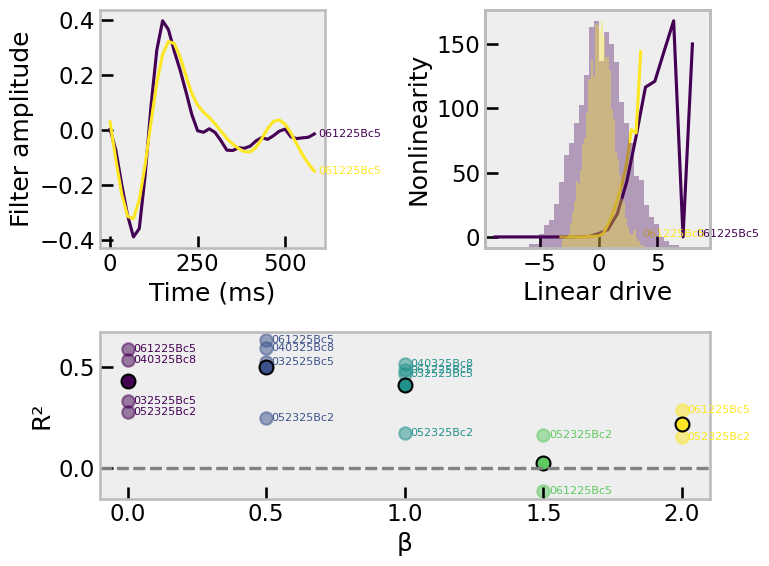

: 

In [ ]:
dt = 1/60
text_cell     = True
plot_single_cell = True
cell_name     = '061225Bc5'
LABEL_MODE_F  = "end"    # 'end' or 'peak' for filters
LABEL_MODE_NL = "end"    # 'end' or 'peak' for NL
PAD_FRAC_F    = 0.02     # horizontal pad (fraction of x-span) for filters
PAD_FRAC_NL   = 0.02     # horizontal pad (fraction of x-span) for NL

fig = plt.figure(figsize=(8,6))
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 0.7])  
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

for _, row in df_celltype.iterrows():
    if row["beta"] != 2.0 and row["beta"] != 0.0:
        continue

    if plot_single_cell and row['cell_name'] != cell_name:
        continue
    color = cmap(norm(row['beta']))

    # ------- Filter panel -------
    filt = np.flip(np.asarray(row['rf_est']))
    t    = np.arange(len(filt)) * bin_size * 1000.0  # ms
    ax1.plot(t, filt, color=color)

    if text_cell:
        if LABEL_MODE_F == "end":
            xF, yF = t[-1], filt[-1]
        elif LABEL_MODE_F == "peak":
            jF = np.argmax(np.abs(filt))
            xF, yF = t[jF], filt[jF]
        dxF = PAD_FRAC_F * (t.max() - t.min())
        ax1.annotate(row['cell_name'], xy=(xF, yF), xytext=(xF + dxF, yF),
                     textcoords='data', ha='left', va='center',
                     fontsize=8, color=color, clip_on=False)

    # ------- NL panel -------
    xNL = np.asarray(row['x_NL'])
    yNL = np.asarray(row['NL'])
    ax2.plot(xNL, yNL/dt, color=color)
    ax_hist = ax2.twinx()
    ax_hist.hist(row['L_est_m'].ravel(), bins=40, density=True, alpha=.35, color=color)
    ax_hist.set_yticks([])

    if text_cell:
        if LABEL_MODE_NL == "end":
            xN, yN = xNL[-1], yNL[-1]
        elif LABEL_MODE_NL == "peak":
            jN = np.argmax(np.abs(yNL))
            xN, yN = xNL[jN], yNL[jN]
        dxN = PAD_FRAC_NL * (xNL.max() - xNL.min())
        ax2.annotate(row['cell_name'], xy=(xN, yN), xytext=(xN + dxN, yN),
                     textcoords='data', ha='left', va='center',
                     fontsize=8, color=color, clip_on=False)

# ------- r² scatter per β -------
for beta, group in df_celltype.groupby("beta"):
    color = cmap(norm(beta))
    ax3.scatter([beta]*len(group), group['r2_test'], color=color, alpha=0.5)
    ax3.axhline(0, ls='--', c='gray', alpha=0.5)
    ax3.scatter(beta, group['r2_test'].mean(), color=color, edgecolor="k", s=100, marker="o")
    for _, r in group.iterrows():
        ax3.text(beta + 0.02, r['r2_test'], r['cell_name'],
                 fontsize=8, color=color, ha='left', va='center')
# Labels
ax1.set_xlabel("Time (ms)");           ax1.set_ylabel("Filter amplitude")
ax2.set_xlabel("Linear drive");        ax2.set_ylabel("Nonlinearity")
ax3.set_xlabel("β");                   ax3.set_ylabel("R²")
# ax3.set_ylim(0.5,1)

fig.tight_layout()
plt.show()



skipping 032525Bc5
skipping 040325Bc8
skipping 052325Bc2
skipping 052325Bc2


C:\Users\SchwartzLab\AppData\Local\Temp\ipykernel_15696\942457758.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


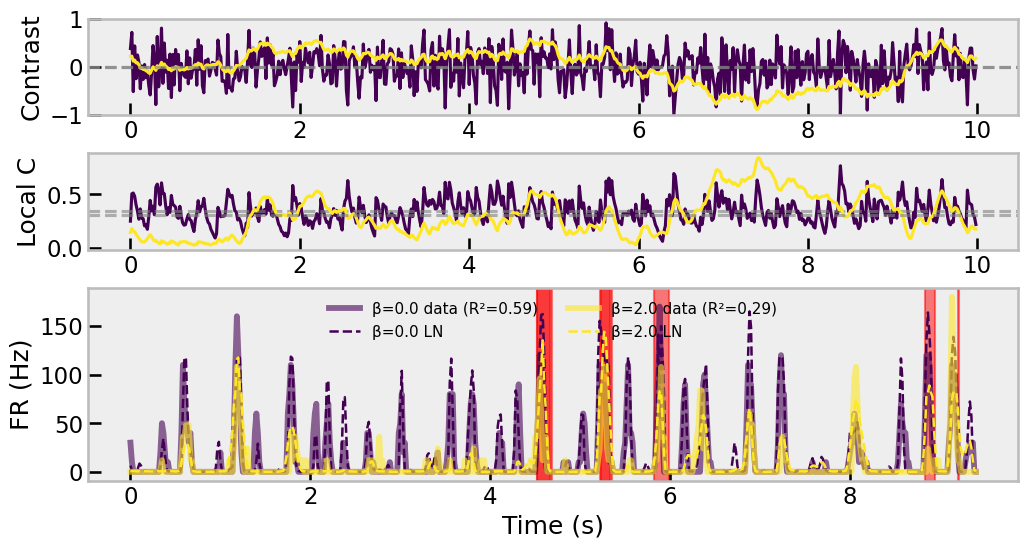

In [41]:

text_cell     = True
plot_single_cell = True
cell_name     = '061225Bc5'
LABEL_MODE_F  = "end"    # 'end' or 'peak' for filters
LABEL_MODE_NL = "end"    # 'end' or 'peak' for NL
PAD_FRAC_F    = 0.02     # horizontal pad (fraction of x-span) for filters
PAD_FRAC_NL   = 0.02     # horizontal pad (fraction of x-span) for NL

fig = plt.figure(figsize=(12,6))
gs = fig.add_gridspec(3, 1, height_ratios=[1.0, 1.0,2.0], hspace=0.3)  
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

for _, row in df_celltype.iterrows():
    beta = row['beta']
    if row["beta"] != 0 and row["beta"] != 2.0:
        continue

    # if row["beta"] != 2:
    #     continue
    if plot_single_cell and row['cell_name'] != cell_name:
        print("skipping", row['cell_name'])
        continue

    color   = cmap(norm(row['beta']))
    # color = 'k'
    stim    = np.asarray(row['stim_rs'][0]) 
    local_c = power_tracker(stim, 1/frame_rate, tau=30/1000)
    psth    = np.asarray(row['psth_real'])
    y_hat   = np.asarray(row['psth_pred'])
    t       = np.arange(len(psth)) * bin_size 
    t_stim  = np.arange(len(stim)) * bin_size
    r2      = r2_score(psth, y_hat)

    ax1.plot(t_stim, stim, color=color)
    ax1.axhline(0, c='gray', ls='--', alpha=0.6)

    ax2.plot(t_stim, local_c, color=color)
    ax2.axhline(np.mean(local_c),  c='gray', ls='--', alpha=0.6)
    ax3.plot(t, psth, color=color, alpha=0.6, lw= 4.2, label=f"β={beta:.1f} data (R²={r2:.2f})")
    ax3.plot(t, y_hat, color=color, linewidth= 1.8, ls='--', label=f'β={beta:.1f} LN')
    spans, mse = top_error_spans(psth, y_hat, t, win_s=0.20, n_spans=5, q=0.95, min_sep_s=0.25)

    # 2) shade them on the PSTH axis
    ymax = ax3.get_ylim()[1]
    for k, (t0, t1, score) in enumerate(spans, 1):
        ax3.axvspan(t0, t1, color='red', alpha=0.5, zorder=0)
        # ax3.text((t0+t1)/2, 0.98*ymax, f'{k}', ha='center', va='top', fontsize=10, color=color)


# Labels
ax1.set_ylabel("Contrast", fontsize=18)  ; ax1.set_ylim((-1,1))        
ax2.set_ylabel("Local C", fontsize=18) 
ax3.set_ylabel("FR (Hz)", fontsize=18)
ax3.set_xlabel("Time (s)", fontsize=18) ;  ax3.legend(loc='upper center', 
                                                      ncol=2, fontsize=11, frameon=False)
# for ax in (ax1, ax2, ax3):
#     ax.set_xlim(4,9)

plt.tight_layout()
plt.show()


In [42]:

import numpy as np

def top_error_spans(y_true, y_pred, t, win_s=0.30, n_spans=3, q=0.98, min_sep_s=0.25):
    """
    Return the top-K time spans where the model deviates most from the data.
    Uses a sliding-window MSE and selects contiguous regions above a high quantile.

    y_true, y_pred: arrays of same length
    t:              time vector (seconds), same length as y_true
    win_s:          sliding window (seconds)
    n_spans:        number of spans to highlight
    q:              quantile threshold (e.g., 0.98 keeps top 2% error)
    min_sep_s:      minimum separation between chosen spans (seconds)
    """
    err = y_true - y_pred
    se  = err**2
    dt  = float(np.mean(np.diff(t)))
    w   = max(1, int(round(win_s / dt)))

    # sliding mean of squared error (centered)
    k    = np.ones(w) / w
    mse  = np.convolve(se, k, mode='same')

    thr  = np.quantile(mse, q)
    mask = mse >= thr

    # find contiguous segments above threshold
    spans = []
    i = 0
    N = len(t)
    while i < N:
        if mask[i]:
            j = i
            while j < N and mask[j]:
                j += 1
            score = float(np.mean(mse[i:j]))
            spans.append((t[i], t[min(j-1, N-1)], score))
            i = j
        else:
            i += 1

    # pick top by score, enforcing min separation
    spans.sort(key=lambda x: x[2], reverse=True)
    picked = []
    for s in spans:
        if all((max(0, min(s[1], p[1]) - max(s[0], p[0])) == 0) and
               (abs((s[0]+s[1])/2 - (p[0]+p[1])/2) >= min_sep_s)
               for p in picked):
            picked.append(s)
            if len(picked) == n_spans:
                break
    return picked, mse


In [43]:
import json
safe_cell_type = re.sub(r'\W+', '_', cell_type.strip())
df_save = df_celltype.copy()
# for col in ["stimulus", "L_est", "spks_data"]:
#     df_save[col] = df_save[col].apply(lambda a: json.dumps(a.tolist()))
if save:
    print("Saving model results...")
    # df_save.to_csv(f'model_results/{safe_cell_type}_LNP_model.csv', index=False)
    df_celltype.to_pickle(f'model_results/{safe_cell_type}_LNP_model.pkl', protocol=5)
    print("Done!")
else: 
    print("Not saving model results this time.")

Not saving model results this time.


In [44]:
import inspect
import textwrap   # handy for removing the leading indentation

# 1) Plain source code ─ what you already did
print(textwrap.dedent(inspect.getsource(sNL)))

# 2) File path where the object lives
print("Defined in:", inspect.getfile(sNL))          # works for anything that came from a .py file



def sNL(L_est_vector, vectorized_spike_train, nbins=40, plotflag=True):
    """
    Computes the empirical nonlinearity (eNL) of a neuron given the
    linear estimate of the visual stimulus (L_est_vector) and the
    corresponding spike train (vectorized_spike_train).

    Parameters
    ----------
    L_est_vector : array_like
        The linear estimate of the visual stimulus.
    vectorized_spike_train : array_like
        The corresponding spike train.
    nbins : int, optional
        The number of bins to use for computing the eNL. Default is 40.
    plotflag : bool, optional
        Whether to plot the eNL. Default is True.

    Returns
    -------
    x_values : array_like
        The values of L_est_vector at the bin centers.
    eNL : array_like
        The mean spike count per bin.
    f_eNL : callable
        The interpolated function of eNL.

    Notes
    -----
    The eNL is computed as the mean spike count per bin of L_est_vector
    after binning the L_est_vector into